In [1]:
from google.colab import drive
drive.mount('/content/drive/')

!pip install open-clip-torch -q
!pip install scikit-learn -q
!pip install seaborn -q

print("Done!")

Mounted at /content/drive/
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00
Done!


In [2]:
import os
import json
import random
import shutil
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import open_clip
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

print("All imports OK")

All imports OK


In [3]:
# ── Seeds ────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark    = True
    torch.backends.cudnn.deterministic = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── Paths ─────────────────────────────────────────────────
# ⚠️ UPDATE THIS to wherever your CiFake weights are saved on Drive
CIFAKE_WEIGHTS_PATH = "/content/drive/MyDrive/deepfake_assignment/results/best_model.pth"

# Where to save Assignment 3 results
A3_SAVE_DIR = "/content/drive/MyDrive/deepfake_assignment/assignment3_cifake"
os.makedirs(A3_SAVE_DIR, exist_ok=True)

# ── Dataset paths ─────────────────────────────────────────
# Changed to save datasets in Google Drive for persistence
RAW_140K_PATH     = "/content/140k_raw"  # downloaded zip
REDUCED_140K_PATH = "/content/drive/MyDrive/deepfake_assignment/data/140k_reduced" # our subset
os.makedirs(RAW_140K_PATH, exist_ok=True)
os.makedirs(REDUCED_140K_PATH, exist_ok=True)

# ── Model settings (must match your A2 CiFake pipeline exactly) ──
BACKBONE_NAME = "ViT-B-16-SigLIP-384"
PRETRAINED    = "webli"
RESOLUTION    = 384
BATCH_SIZE    = 32
NUM_WORKERS   = 0

# ── Training settings (for fresh training on 140k) ────────
EPOCHS       = 10
LR           = 2e-4
WEIGHT_DECAY = 0.01
DROPOUT      = 0.10
NOISE_STD    = 0.02

# ── Subset size ───────────────────────────────────────────
# 140k dataset already has train/valid/test splits
# We sample 5000 per class from each split
SAMPLES_PER_CLASS_TRAIN = 5000
SAMPLES_PER_CLASS_VALID = 1000
SAMPLES_PER_CLASS_TEST  = 1000

# ── Paper targets for comparison ──────────────────────────
PAPER_CIFAKE_ACCURACY = 95.0
PAPER_CIFAKE_AUC      = 0.986

print("Config done!")
print(f"CiFake weights path : {CIFAKE_WEIGHTS_PATH}")
print(f"Weights exist       : {os.path.exists(CIFAKE_WEIGHTS_PATH)}")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Config done!
CiFake weights path : /content/drive/MyDrive/deepfake_assignment/results/best_model.pth
Weights exist       : True


In [4]:
class SigLIP2Classifier(nn.Module):
    """
    Exact same architecture as Assignment 2 CiFake pipeline.
    Must match exactly for weights to load correctly.
    """
    def __init__(
        self,
        backbone_name: str = "ViT-B-16-SigLIP-384",
        pretrained:    str = "webli",
        device:        torch.device = torch.device("cpu"),
        dropout:       float = 0.10,
        noise_std:     float = 0.02,
    ):
        super().__init__()
        self.noise_std = noise_std

        # Frozen backbone
        backbone, _, _ = open_clip.create_model_and_transforms(
            backbone_name, pretrained=pretrained, device=device
        )
        self.backbone = backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        # Infer feature dimension
        with torch.no_grad():
            dummy = torch.zeros(1, 3, RESOLUTION, RESOLUTION, device=device)
            feat_dim = self.backbone.encode_image(dummy).shape[-1]

        self.layer_norm = nn.LayerNorm(feat_dim)

        # MLP head — must match A2 exactly
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

        print(f"Backbone : {backbone_name}  (FROZEN)")
        print(f"Feat dim : {feat_dim}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            feats = self.backbone.encode_image(x)
        feats = F.normalize(feats, dim=-1)
        if self.training and self.noise_std > 0:
            feats = feats + torch.randn_like(feats) * self.noise_std
        feats = self.layer_norm(feats)
        return self.head(feats).squeeze(-1)

In [5]:
# Build model
cifake_model = SigLIP2Classifier(
    backbone_name = BACKBONE_NAME,
    pretrained     = PRETRAINED,
    device        = DEVICE,
    dropout       = DROPOUT,
    noise_std     = NOISE_STD,
).to(DEVICE)

# Load saved weights
ckpt = torch.load(CIFAKE_WEIGHTS_PATH, map_location=DEVICE, weights_only=False)
cifake_model.load_state_dict(ckpt["model_state_dict"])

print(f"\n✓ CiFake weights loaded successfully!")
print(f"  Saved at epoch : {ckpt.get('epoch', 'N/A')}")
print(f"  Val F1         : {ckpt.get('val_f1', 'N/A')}")
print(f"  Val Acc        : {ckpt.get('val_acc', 'N/A')}")
print(f"  Val AUC        : {ckpt.get('val_auc', 'N/A')}")

open_clip_model.safetensors:   0%|          | 0.00/814M [00:00<?, ?B/s]

Backbone : ViT-B-16-SigLIP-384  (FROZEN)
Feat dim : 768

✓ CiFake weights loaded successfully!
  Saved at epoch : 6
  Val F1         : 0.9201065246338216
  Val Acc        : 92.0
  Val AUC        : 0.9762302222222222


In [8]:
# import os
# # Upload your kaggle.json first if not already done
# from google.colab import files
# # files.upload()   # uncomment if needed

# # Setup Kaggle API
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# # Download dataset (~4 GB)
# os.makedirs(RAW_140K_PATH, exist_ok=True)
# print("Downloading 140k Real and Fake Faces...")
# !kaggle datasets download -d xhlulu/140k-real-and-fake-faces -p {RAW_140K_PATH}

# Unzip
print("Extracting...")
!unzip -o {RAW_140K_PATH}/140k-real-and-fake-faces.zip -d {RAW_140K_PATH}

# Check structure
print("\nFolder structure:")
for split in ['train', 'valid', 'test']:
    for label in ['real', 'fake']:
        folder = os.path.join(RAW_140K_PATH, 'real_vs_fake',
                              'real_vs_fake', split, label)
        if os.path.exists(folder):
            count = len(os.listdir(folder))
            print(f"  {split}/{label}: {count:,} images \u2713")
        else:
            print(f"  {split}/{label}: NOT FOUND \u2717")

Streaming output truncated to the last 5000 lines.
  inflating: /content/140k_raw/real_vs_fake/real-vs-fake/valid/real/34868.jpg  
  inflating: /content/140k_raw/real_vs_fake/real-vs-fake/valid/real/34877.jpg  
  inflating: /content/140k_raw/real_vs_fake/real-vs-fake/valid/real/34883.jpg  
  inflating: /content/140k_raw/real_vs_fake/real-vs-fake/valid/real/34887.jpg  
  inflating: /content/140k_raw/real_vs_fake/real-vs-fake/valid/real/34891.jpg  
  inflating: /content/140k_raw/real_vs_fake/real-vs-fake/valid/real/34894.jpg  
  inflating: /content/140k_raw/real_vs_fake/real-vs-fake/valid/real/34904.jpg  
  inflating: /content/140k_raw/real_vs_fake/real-vs-fake/valid/real/34905.jpg  
  inflating: /content/140k_raw/real_vs_fake/real-vs-fake/valid/real/34911.jpg  
  inflating: /content/140k_raw/real_vs_fake/real-vs-fake/valid/real/34935.jpg  
  inflating: /content/140k_raw/real_vs_fake/real-vs-fake/valid/real/34943.jpg  
  inflating: /content/140k_raw/real_vs_fake/real-vs-fake/valid/real/3

In [9]:
def reduce_140k_dataset(
    raw_root:   str,
    dst_root:   str,
    train_per_class: int = 5000,
    valid_per_class: int = 1000,
    test_per_class:  int = 1000,
    seed: int = 42,
):
    """
    140k dataset uses lowercase 'real' and 'fake' folder names.
    Structure: raw_root/real-vs-fake/real-vs-fake/train/real/
    We copy a subset into a clean structure at dst_root.
    """
    random.seed(seed)

    # Find the actual root inside the zip
    actual_root = os.path.join(raw_root, 'real_vs_fake', 'real-vs-fake') # Corrected: real-vs-fake

    split_sizes = {
        'train': train_per_class,
        'valid': valid_per_class,
        'test' : test_per_class,
    }

    print("Creating reduced 140k dataset...")
    print("-" * 44)

    for split, n_per_class in split_sizes.items():
        for label in ['real', 'fake']:
            src = os.path.join(actual_root, split, label)
            dst = os.path.join(dst_root, split, label)
            os.makedirs(dst, exist_ok=True)

            all_imgs = [
                f for f in os.listdir(src)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ]

            # Sample subset
            selected = random.sample(
                all_imgs, min(n_per_class, len(all_imgs))
            )

            for fname in selected:
                shutil.copy2(
                    os.path.join(src, fname),
                    os.path.join(dst, fname)
                )

        print(f"  {split:5s}: {n_per_class:,} real + "
              f"{n_per_class:,} fake copied")

    # Verify
    print("\nVerification:")
    print("-" * 44)
    total = 0
    for split in ['train', 'valid', 'test']:
        for label in ['real', 'fake']:
            folder = os.path.join(dst_root, split, label)
            n = len(os.listdir(folder))
            total += n
            print(f"  {split:5s}/{label}: {n:,} ✓")
    print("-" * 44)
    print(f"  Grand total: {total:,} images")

reduce_140k_dataset(
    raw_root        = RAW_140K_PATH,
    dst_root        = REDUCED_140K_PATH,
    train_per_class = SAMPLES_PER_CLASS_TRAIN,
    valid_per_class = SAMPLES_PER_CLASS_VALID,
    test_per_class  = SAMPLES_PER_CLASS_TEST,
)

Creating reduced 140k dataset...
--------------------------------------------
  train: 5,000 real + 5,000 fake copied
  valid: 1,000 real + 1,000 fake copied
  test : 1,000 real + 1,000 fake copied

Verification:
--------------------------------------------
  train/real: 5,000 ✓
  train/fake: 5,000 ✓
  valid/real: 1,000 ✓
  valid/fake: 1,000 ✓
  test /real: 1,000 ✓
  test /fake: 1,000 ✓
--------------------------------------------
  Grand total: 14,000 images


In [10]:
class FaceDataset(Dataset):
    """
    Loads 140k Real & Fake Faces.
    Folder names: real / fake  (lowercase)
    Labels      : real = 0, fake = 1
    """
    def __init__(self, root: str, split: str, transform):
        self.transform = transform
        self.samples   = []
        self.labels    = []

        for label_idx, class_name in enumerate(["real", "fake"]):
            folder = os.path.join(root, split, class_name)
            if not os.path.exists(folder):
                raise FileNotFoundError(f"Not found: {folder}")
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append(os.path.join(folder, fname))
                    self.labels.append(label_idx)

        n_real = self.labels.count(0)
        n_fake = self.labels.count(1)
        print(f"  [{split:5s}]  real={n_real:,}  fake={n_fake:,}  "
              f"total={len(self.samples):,}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx], self.labels[idx]
        image = Image.open(path).convert("RGB")
        return self.transform(image), label


def build_transforms(resolution: int):
    norm = transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std =[0.5, 0.5, 0.5]
    )
    eval_tf = transforms.Compose([
        transforms.Resize((resolution, resolution)),
        transforms.ToTensor(),
        norm,
    ])
    train_tf = transforms.Compose([
        transforms.Resize((resolution, resolution)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        norm,
    ])
    return train_tf, eval_tf


def build_loaders(root, resolution, batch_size, num_workers):
    train_tf, eval_tf = build_transforms(resolution)
    print("Loading 140k dataset:")
    train_ds = FaceDataset(root, "train", train_tf)
    valid_ds  = FaceDataset(root, "valid",  eval_tf)
    test_ds  = FaceDataset(root, "test",  eval_tf)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size,
        shuffle=True,  num_workers=num_workers, pin_memory=True
    )
    valid_loader = DataLoader(
        valid_ds, batch_size=batch_size,
        shuffle=False, num_workers=num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size,
        shuffle=False, num_workers=num_workers, pin_memory=True
    )
    return train_loader, valid_loader, test_loader

In [11]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []

    for images, labels in tqdm(loader, desc="  Eval", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)

        with torch.amp.autocast("cuda"):
            logits = model(images)
            loss   = criterion(logits, labels)

        total_loss += loss.item()
        all_labels.append(labels.cpu().numpy())
        all_probs.append(torch.sigmoid(logits).cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_probs  = np.concatenate(all_probs)
    all_preds  = (all_probs > 0.5).astype(int)

    return {
        "loss"    : total_loss / len(loader),
        "accuracy": 100.0 * accuracy_score(all_labels, all_preds),
        "f1"      : f1_score(all_labels, all_preds, zero_division=0),
        "auc"     : roc_auc_score(all_labels, all_probs),
        "ap"      : average_precision_score(all_labels, all_probs),
        "labels"  : all_labels,
        "probs"   : all_probs,
    }

In [12]:
# Build data loaders for 140k test set
_, _, test_loader_140k = build_loaders(
    root        = REDUCED_140K_PATH,
    resolution  = RESOLUTION,
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
)

criterion = nn.BCEWithLogitsLoss()

print("=" * 55)
print("EXPERIMENT 1: Cross-Domain Test")
print("  Model trained on : CiFake (diffusion fakes)")
print("  Tested on        : 140k Real & Fake Faces (GAN fakes)")
print("=" * 55)

cross_domain_results = evaluate(
    cifake_model, test_loader_140k, criterion, DEVICE
)

print(f"\nCross-Domain Results:")
print(f"  Accuracy : {cross_domain_results['accuracy']:.2f}%")
print(f"  AUC-ROC  : {cross_domain_results['auc']:.4f}")
print(f"  F1-Score : {cross_domain_results['f1']:.4f}")
print(f"  Avg Prec : {cross_domain_results['ap']:.4f}")

# Save results
with open(os.path.join(A3_SAVE_DIR, "cross_domain_results.json"), "w") as f:
    json.dump({
        "experiment"      : "cross_domain_cifake_to_140k",
        "train_dataset"   : "CiFake",
        "test_dataset"    : "140k Real & Fake Faces",
        "accuracy"        : float(cross_domain_results['accuracy']),
        "auc"             : float(cross_domain_results['auc']),
        "f1"              : float(cross_domain_results['f1']),
        "ap"              : float(cross_domain_results['ap']),
    }, f, indent=2)

print("\n✓ Cross-domain results saved!")

Loading 140k dataset:
  [train]  real=5,000  fake=5,000  total=10,000
  [valid]  real=1,000  fake=1,000  total=2,000
  [test ]  real=1,000  fake=1,000  total=2,000
EXPERIMENT 1: Cross-Domain Test
  Model trained on : CiFake (diffusion fakes)
  Tested on        : 140k Real & Fake Faces (GAN fakes)



Cross-Domain Results:
  Accuracy : 46.00%
  AUC-ROC  : 0.4303
  F1-Score : 0.5292
  Avg Prec : 0.4356

✓ Cross-domain results saved!


In [13]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total   = 0

    pbar = tqdm(loader, desc="  Train", leave=False)
    for idx, (images, labels) in enumerate(pbar):
        images = images.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda"):
            logits = model(images)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds       = (torch.sigmoid(logits) > 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += labels.size(0)

        # Only update every N batches (e.g., every 50 batches)
        if idx % 50 == 0:
            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc" : f"{100*correct/total:.1f}%"
            })

    return total_loss / len(loader), 100.0 * correct / total

# Build all loaders for 140k
train_loader_140k, valid_loader_140k, test_loader_140k = build_loaders(
    root        = REDUCED_140K_PATH,
    resolution  = RESOLUTION,
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
)

# Build a fresh model (do not reuse cifake_model weights)
fresh_model = SigLIP2Classifier(
    backbone_name = BACKBONE_NAME,
    pretrained    = PRETRAINED,
    device        = DEVICE,
    dropout       = DROPOUT,
    noise_std     = NOISE_STD,
).to(DEVICE)

optimizer = optim.AdamW(
    fresh_model.head.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)
scaler    = torch.amp.GradScaler("cuda")
criterion = nn.BCEWithLogitsLoss()

# Training history
history = {k: [] for k in
           ["train_loss", "train_acc",
            "val_loss",   "val_acc",
            "val_f1",     "val_auc"]}

best_val_f1  = 0.0
best_epoch   = 0
ckpt_140k    = os.path.join(A3_SAVE_DIR, "best_140k_model.pth")

print("\n" + "=" * 55)
print(f"EXPERIMENT 2: Train fresh on 140k dataset ({EPOCHS} epochs)")
print("=" * 55)

for epoch in range(1, EPOCHS + 1):
    lr = scheduler.get_last_lr()[0]
    print(f"\nEpoch {epoch}/{EPOCHS}  (lr={lr:.2e})")

    train_loss, train_acc = train_one_epoch(
        fresh_model, train_loader_140k,
        criterion, optimizer, scaler, DEVICE
    )
    val_res = evaluate(
        fresh_model, valid_loader_140k, criterion, DEVICE
    )
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_res["loss"])
    history["val_acc"].append(val_res["accuracy"])
    history["val_f1"].append(val_res["f1"])
    history["val_auc"].append(val_res["auc"])

    print(f"  Train  loss={train_loss:.4f}  acc={train_acc:.2f}%")
    print(f"  Val    loss={val_res['loss']:.4f}  "
          f"acc={val_res['accuracy']:.2f}%  "
          f"f1={val_res['f1']:.4f}  "
          f"auc={val_res['auc']:.4f}")

    if val_res["f1"] > best_val_f1:
        best_val_f1 = val_res["f1"]
        best_epoch  = epoch
        torch.save({
            "epoch"            : epoch,
            "model_state_dict" : fresh_model.state_dict(),
            "val_f1"           : val_res["f1"],
            "val_acc"          : val_res["accuracy"],
            "val_auc"          : val_res["auc"],
        }, ckpt_140k)
        print(f"  ✓ Best model saved (val_f1={best_val_f1:.4f})")

print(f"\nTraining done. Best epoch: {best_epoch}  Val F1: {best_val_f1:.4f}")

Loading 140k dataset:
  [train]  real=5,000  fake=5,000  total=10,000
  [valid]  real=1,000  fake=1,000  total=2,000
  [test ]  real=1,000  fake=1,000  total=2,000
Backbone : ViT-B-16-SigLIP-384  (FROZEN)
Feat dim : 768

EXPERIMENT 2: Train fresh on 140k dataset (10 epochs)

Epoch 1/10  (lr=2.00e-04)


  Train  loss=0.4212  acc=81.23%
  Val    loss=0.2515  acc=90.85%  f1=0.9094  auc=0.9708
  ✓ Best model saved (val_f1=0.9094)

Epoch 2/10  (lr=1.95e-04)


  Train  loss=0.2829  acc=88.37%
  Val    loss=0.1960  acc=92.60%  f1=0.9284  auc=0.9813
  ✓ Best model saved (val_f1=0.9284)

Epoch 3/10  (lr=1.81e-04)


  Train  loss=0.2604  acc=89.31%
  Val    loss=0.1664  acc=94.25%  f1=0.9438  auc=0.9861
  ✓ Best model saved (val_f1=0.9438)

Epoch 4/10  (lr=1.59e-04)


  Train  loss=0.2506  acc=89.59%
  Val    loss=0.1556  acc=94.50%  f1=0.9454  auc=0.9868
  ✓ Best model saved (val_f1=0.9454)

Epoch 5/10  (lr=1.31e-04)


...

  Train  loss=0.2406  acc=89.98%
  Val    loss=0.1491  acc=94.85%  f1=0.9497  auc=0.9882
  ✓ Best model saved (val_f1=0.9497)

Epoch 7/10  (lr=6.98e-05)


  Train  loss=0.2374  acc=90.10%
  Val    loss=0.1454  acc=95.00%  f1=0.9511  auc=0.9888
  ✓ Best model saved (val_f1=0.9511)

Epoch 8/10  (lr=4.20e-05)


  Train  loss=0.2391  acc=89.88%
  Val    loss=0.1461  acc=94.95%  f1=0.9507  auc=0.9890

Epoch 9/10  (lr=2.00e-05)


  Train  loss=0.2368  acc=90.12%
  Val    loss=0.1433  acc=95.10%  f1=0.9520  auc=0.9891
  ✓ Best model saved (val_f1=0.9520)

Epoch 10/10  (lr=5.87e-06)


  Train  loss=0.2349  acc=90.13%
  Val    loss=0.1426  acc=95.05%  f1=0.9515  auc=0.9891

Training done. Best epoch: 9  Val F1: 0.9520



  ASSIGNMENT 3 — COMPLETE RESULTS TABLE
  Experiment                              Acc     AUC      F1
-----------------------------------------------------------------
  Paper — CiFake                        95.0%   0.986   ~0.95
  Our A2 — CiFake (from ckpt)               ?       ?       ?
  Cross-domain: CiFake→140k            46.00%   0.430   0.529
  Trained on 140k → tested on 140k     94.40%   0.990   0.945


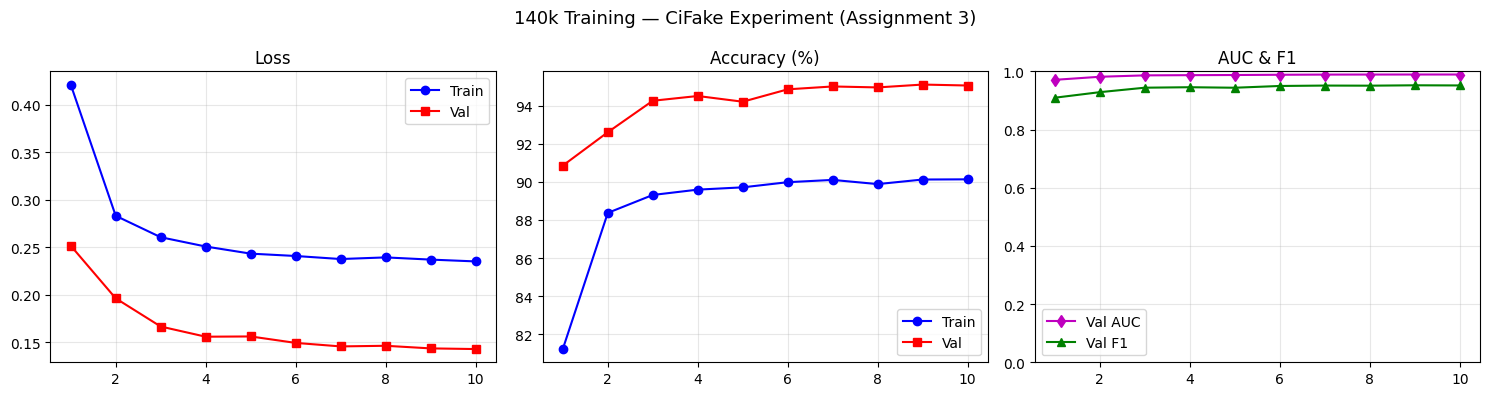

Saved → /content/drive/MyDrive/deepfake_assignment/assignment3_cifake/140k_training_curves.png


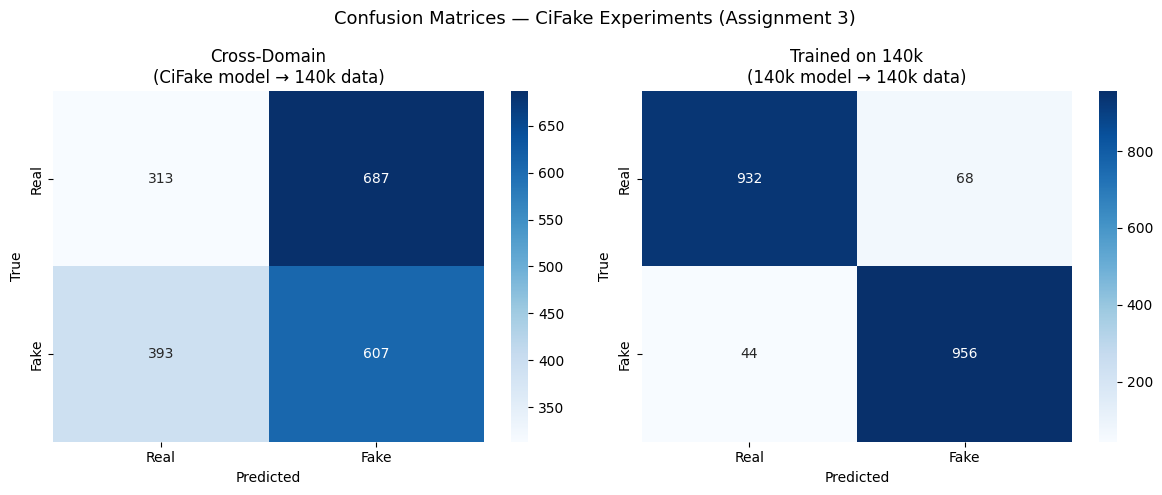

Saved → /content/drive/MyDrive/deepfake_assignment/assignment3_cifake/confusion_matrices.png


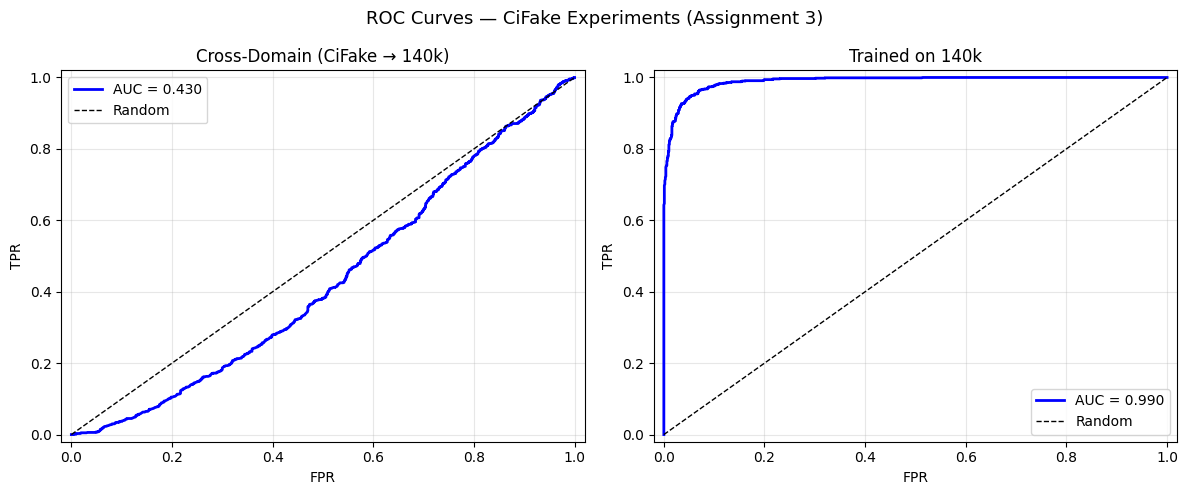

Saved → /content/drive/MyDrive/deepfake_assignment/assignment3_cifake/roc_curves.png

✓ All Assignment 3 CiFake results saved to Drive!
  Folder: /content/drive/MyDrive/deepfake_assignment/assignment3_cifake


In [15]:
# Load best 140k model
ckpt = torch.load(ckpt_140k, map_location=DEVICE, weights_only=False)
fresh_model.load_state_dict(ckpt["model_state_dict"])

# Final test evaluation
test_res_140k = evaluate(
    fresh_model, test_loader_140k, criterion, DEVICE
)

# ── Print comparison table ────────────────────────────────
print("\n" + "=" * 65)
print("  ASSIGNMENT 3 — COMPLETE RESULTS TABLE")
print("=" * 65)
print(f"  {'Experiment':<35} {'Acc':>7} {'AUC':>7} {'F1':>7}")
print("-" * 65)
print(f"  {'Paper — CiFake':<35} {'95.0%':>7} {'0.986':>7} {'~0.95':>7}")
print(f"  {'Our A2 — CiFake (from ckpt)':<35} "
      f"{'?':>7} {'?':>7} {'?':>7}")   # fill with your A2 numbers
print(f"  {'Cross-domain: CiFake→140k':<35} "
      f"{cross_domain_results['accuracy']:>6.2f}% "
      f"{cross_domain_results['auc']:>7.3f} "
      f"{cross_domain_results['f1']:>7.3f}")
print(f"  {'Trained on 140k → tested on 140k':<35} "
      f"{test_res_140k['accuracy']:>6.2f}% "
      f"{test_res_140k['auc']:>7.3f} "
      f"{test_res_140k['f1']:>7.3f}")
print("=" * 65)

# ── Training curves ───────────────────────────────────────
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("140k Training — CiFake Experiment (Assignment 3)", fontsize=13)

axes[0].plot(epochs, history["train_loss"], "b-o", label="Train")
axes[0].plot(epochs, history["val_loss"],   "r-s", label="Val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], "b-o", label="Train")
axes[1].plot(epochs, history["val_acc"],   "r-s", label="Val")
axes[1].set_title("Accuracy (%)"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history["val_auc"], "m-d", label="Val AUC")
axes[2].plot(epochs, history["val_f1"],  "g-^", label="Val F1")
axes[2].set_ylim([0, 1]); axes[2].set_title("AUC & F1")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
curve_path = os.path.join(A3_SAVE_DIR, "140k_training_curves.png")
plt.savefig(curve_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {curve_path}")

# ── Confusion matrices side by side ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices — CiFake Experiments (Assignment 3)", fontsize=13)

for ax, res, title in [
    (axes[0], cross_domain_results, "Cross-Domain\n(CiFake model → 140k data)"),
    (axes[1], test_res_140k,        "Trained on 140k\n(140k model → 140k data)"),
]:
    cm = confusion_matrix(res["labels"], (res["probs"] > 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Real", "Fake"],
                yticklabels=["Real", "Fake"])
    ax.set_title(title)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.tight_layout()
cm_path = os.path.join(A3_SAVE_DIR, "confusion_matrices.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {cm_path}")

# ── ROC curves side by side ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("ROC Curves — CiFake Experiments (Assignment 3)", fontsize=13)

for ax, res, title in [
    (axes[0], cross_domain_results, "Cross-Domain (CiFake → 140k)"),
    (axes[1], test_res_140k,        "Trained on 140k"),
]:
    fpr, tpr, _ = roc_curve(res["labels"], res["probs"])
    ax.plot(fpr, tpr, "b-", lw=2, label=f"AUC = {res['auc']:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
roc_path = os.path.join(A3_SAVE_DIR, "roc_curves.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {roc_path}")

# ── Save all results to JSON ──────────────────────────────
all_results = {
    "cross_domain": {
        "train_dataset" : "CiFake",
        "test_dataset"  : "140k Real & Fake Faces",
        "accuracy"      : float(cross_domain_results["accuracy"]),
        "auc"           : float(cross_domain_results["auc"]),
        "f1"            : float(cross_domain_results["f1"]),
        "ap"            : float(cross_domain_results["ap"]),
    },
    "trained_on_140k": {
        "train_dataset" : "140k Real & Fake Faces",
        "test_dataset"  : "140k Real & Fake Faces",
        "accuracy"      : float(test_res_140k["accuracy"]),
        "auc"           : float(test_res_140k["auc"]),
        "f1"            : float(test_res_140k["f1"]),
        "ap"            : float(test_res_140k["ap"]),
    },
    "training_history": history,
}
with open(os.path.join(A3_SAVE_DIR, "all_results.json"), "w") as f:
    json.dump(all_results, f, indent=2)

print("\n✓ All Assignment 3 CiFake results saved to Drive!")
print(f"  Folder: {A3_SAVE_DIR}")